In [17]:
import shap

In [18]:
from sklearn.datasets import load_diabetes, load_iris

In [19]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# **Regression**

In [20]:
x, y = load_diabetes(return_X_y=True)

In [21]:
features = load_diabetes()["feature_names"]

In [22]:
features

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.3,
    random_state = 11
)

In [24]:
rfr = RandomForestRegressor(random_state=11)

In [25]:
rfr.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
exp = shap.TreeExplainer(rfr)

In [27]:
shap_values = exp.shap_values(x_test)

In [28]:
shap_values

array([[-8.50612512e+00,  4.53459422e+00, -2.89555023e+01, ...,
         3.56188206e-02, -2.20649507e+01, -3.07134210e+00],
       [-4.04501261e+00, -3.84819770e+00, -2.66662583e+01, ...,
        -3.65531650e-01, -2.07288505e+01, -3.61578619e+00],
       [ 5.79532350e+00,  2.85050607e+00, -4.91732513e+00, ...,
        -1.29027549e+00,  6.81412792e+00,  3.03405807e-02],
       ...,
       [-3.98286146e+00,  3.32126855e+00, -2.43276023e+01, ...,
        -1.14100087e-01, -2.01146707e+01, -3.94306425e+00],
       [-7.69342777e+00,  2.48093582e+00,  5.22104806e+01, ...,
        -6.28754552e-01,  1.38480675e+01, -9.79820652e+00],
       [-2.92288631e+00, -3.28270871e+00,  4.90758889e+00, ...,
        -1.59111923e-01, -2.25791204e+01,  2.72692907e+00]],
      shape=(133, 10))

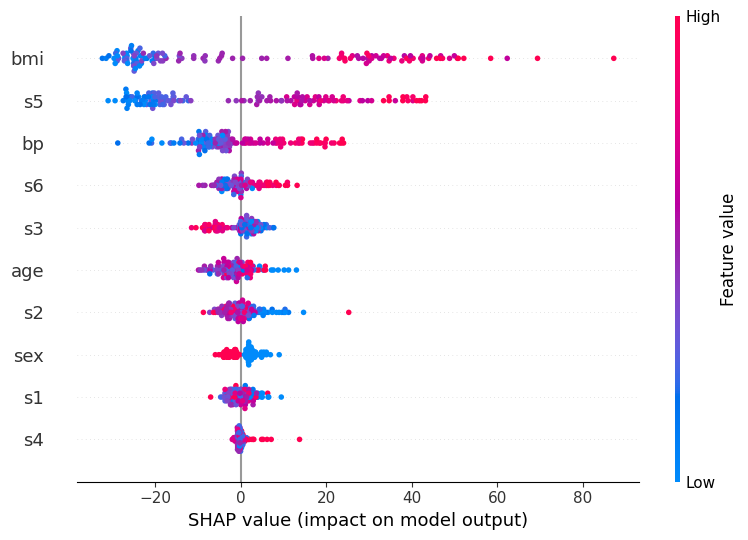

In [29]:
shap.summary_plot(shap_values, x_test, feature_names=features)

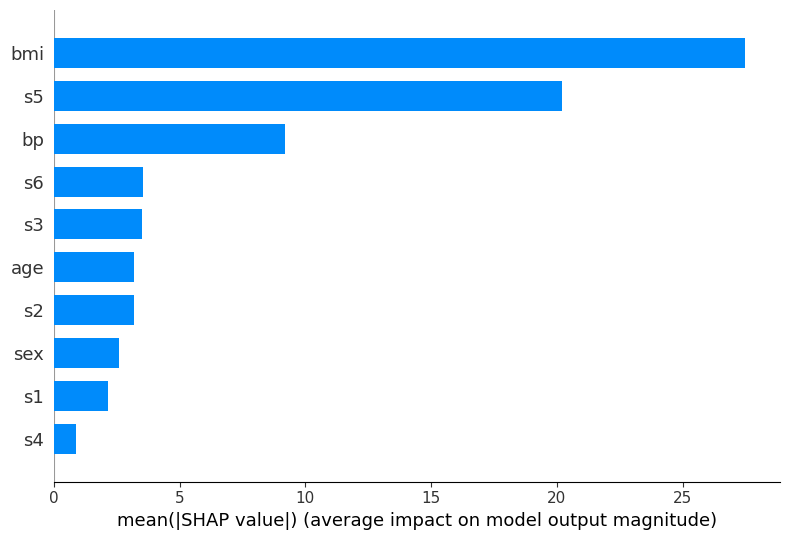

In [30]:
shap.summary_plot(shap_values, x_test, feature_names=features, plot_type = "bar")

In [34]:
shap.initjs()
shap.force_plot(exp.expected_value, shap_values[100, :], x_test[100, :], feature_names=features)

# **Classification**

In [35]:
x, y = load_iris(return_X_y = True)

In [37]:
features = load_iris()["feature_names"]

In [38]:
classes = load_iris()["target_names"]

In [39]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.3,
    random_state = 11
)

In [40]:
rfc = RandomForestClassifier(random_state=11)

In [41]:
rfc.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [42]:
explainer = shap.TreeExplainer(rfc)

In [43]:
shap_values = explainer.shap_values(x_test)

In [45]:
shap_values

array([[[-4.95227068e-02, -2.12911534e-02,  7.08138601e-02],
        [-9.89516933e-04, -1.21357947e-02,  1.31253117e-02],
        [-1.18839862e-01, -1.35544964e-01,  2.54384826e-01],
        [-1.76171724e-01, -1.72266183e-01,  3.48437907e-01]],

       [[-4.95138884e-02, -1.97643013e-02,  6.92781897e-02],
        [-9.89516933e-04, -1.25728244e-02,  1.35623413e-02],
        [-1.18778134e-01, -1.01398909e-01,  2.20177043e-01],
        [-1.76242271e-01, -2.07502060e-01,  3.83744331e-01]],

       [[-3.85941879e-02,  3.28148454e-04,  3.82660394e-02],
        [-1.75107936e-02,  1.20269949e-02,  5.48379866e-03],
        [-1.21426945e-01, -7.48137478e-02,  1.96240693e-01],
        [-1.67991883e-01,  3.71220509e-01, -2.03228626e-01]],

       [[-4.90664014e-02,  6.80232142e-03,  4.22640800e-02],
        [ 3.67663508e-03,  4.82833099e-03, -8.50496607e-03],
        [-1.19513604e-01,  2.79466211e-01, -1.59952607e-01],
        [-1.80620439e-01,  3.76650410e-02,  1.42955398e-01]],

       [[-3.3677

In [46]:
len(shap_values)

45

In [51]:
old_style_shap = [
    shap_values[:, :, i]
    for i in range(shap_values.shape[2])
]

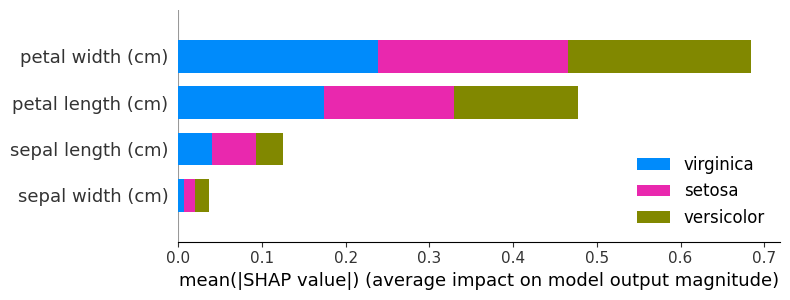

In [52]:
shap.summary_plot(
    old_style_shap,
    x_test,
    feature_names=features,
    class_names=classes
)

In [58]:
shap.initjs()
shap.force_plot(exp.expected_value[0], shap_values[0, :, 2], x_test[0, :], feature_names=features)

In [56]:
shap.initjs()
shap.force_plot(exp.expected_value[0], shap_values[0, :, 1], x_test[0, :], feature_names=features)

In [57]:
shap.initjs()
shap.force_plot(exp.expected_value[0], shap_values[0, :, 0], x_test[0, :], feature_names=features)